# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll join the official morphology labels to flat image files, build an `ImageFolder`-ready layout, create a `DataLoader` yielding `(32, 3, 64, 64)` batches, and plot a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

> **Heads-up:** The [Kaggle Galaxy Zoo 2 download](https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images) does **not** ship class subfolders. Images are named `{asset_id}.jpg` in a flat folder; labels live in CSV catalogues. We join them first, then use `ImageFolder`.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [1]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

The Kaggle bundle contains:
- `images_gz2.zip` — ~243k JPGs named `1.jpg`, `2.jpg`, … (no class folders)
- `gz2_filename_mapping.csv` — maps each `asset_id` to an SDSS `objid`

Morphology labels come separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)), which we download as `gz2_hart16.csv.gz`.

**Option A — Kaggle API (recommended).** Upload your `kaggle.json` token, then run the download/unzip commands in the solution notebook (or adapt the cell below).

Fill in the cell below to download/locate the data and set the paths.

In [2]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('gal_morph')

!pip install -q kaggle

In [3]:
# TODO: download + unzip the Kaggle dataset and Hart et al. labels.
#       Set RAW_ROOT (raw download), IMAGES_DIR (flat JPG folder), and DATA_ROOT (organized for ImageFolder).
#
# Expected after setup:
#   RAW_ROOT/gz2_filename_mapping.csv
#   IMAGES_DIR/123.jpg, IMAGES_DIR/124.jpg, ...
#   RAW_ROOT/gz2_hart16.csv
#   DATA_ROOT/elliptical/*.jpg  (you create this in Step 3)
RAW_ROOT = Path("galaxy_raw")      # <-- set up download here
IMAGES_DIR = RAW_ROOT / "images_gz2"  # flat image folder
DATA_ROOT = Path("galaxy_data")    # ImageFolder root (built in Step 3)

RAW_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
!unzip -q {RAW_ROOT}/galaxy-zoo-2-images.zip -d {RAW_ROOT}
print("Files extracted")

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [02:55<00:00, 18.7MB/s]

Files extracted


## Step 2 — Inspect the raw layout

List what's inside `RAW_ROOT` and peek at `IMAGES_DIR`. You should see a CSV mapping file and many JPGs named by integer ID — **not** morphology subfolders.

Also open `gz2_filename_mapping.csv` and confirm columns `objid`, `sample`, `asset_id`.

the images are nested further, so IMAGES_DIR is updated

In [6]:
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"

In [7]:
# TODO: print os.listdir(RAW_ROOT) and count a few files in IMAGES_DIR.
#       Hint: Path(IMAGES_DIR).glob("*.jpg")
try:
  print(os.listdir(RAW_ROOT))
except Exception as e:
  print(f"Error: {e}")

jpg_files = list(Path(IMAGES_DIR).glob("*.jpg"))
file_count = len(jpg_files) # total number of files found
print(f"Total .jpg files in IMAGES_DIR: {file_count}")
print("First few files:")
for file in jpg_files[:5]:
    print(f" - {file.name}")

['images_gz2', 'galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv']
Total .jpg files in IMAGES_DIR: 243434
First few files:
 - 135418.jpg
 - 179026.jpg
 - 62305.jpg
 - 217760.jpg
 - 180837.jpg


## Step 3 — Join labels and build an ImageFolder layout

`ImageFolder` expects `root/<class_name>/<image>.jpg`. Our Kaggle download doesn't provide that, so we:

1. Merge `gz2_filename_mapping.csv` with `gz2_hart16.csv` on `objid`.
2. Collapse the detailed `gz2_class` string (e.g. `Sc2t`, `Ei`) into a few high-level buckets.
3. Symlink a **balanced subset** into `DATA_ROOT/<class>/` so Colab stays fast.

Implement `high_level_label(gz2_class)` and `build_imagefolder_layout(...)` — see [`08-data-pipelines.md`](../08-data-pipelines.md).

In [8]:
RAW_ROOT_ = Path("galaxy_raw")
print("Downloading gz2_hart16.csv")
!wget -P {RAW_ROOT_} https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

print("Extracting labels file")
!gunzip -f {RAW_ROOT_}/gz2_hart16.csv.gz

--2026-06-06 17:34:58--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.212.254, 52.216.33.97, 16.15.244.159, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.212.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘galaxy_raw/gz2_hart16.csv.gz’

gz2_hart16.csv.gz   100%[===================>]  74.88M  16.7MB/s    in 5.7s    

2026-06-06 17:35:05 (13.2 MB/s) - ‘galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]

Extracting labels file


In [9]:
print(os.listdir(RAW_ROOT))

['images_gz2', 'galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv']


In [13]:
# TODO: define high_level_label(gz2_class) -> str | None
#       E* -> "elliptical", SB* -> "spiral_barred", S* -> "spiral"; skip "A" (artifact)
def high_level_label(gz2_class):
  if "E" in gz2_class:
    return "elliptical"
  elif "SB" in gz2_class:
    return "spiral_barred"
  elif "S" in gz2_class:
    return "spiral"
  else:
    return None

# TODO: define build_imagefolder_layout(...) that merges CSVs and symlinks
#       PER_CLASS images per class into DATA_ROOT/<label>/.
#       Call it once with PER_CLASS = 200 (or similar).
def build_imagefolder_layout(images_dir, mapping_csv,labels_csv, out_root, per_class=200, seed=42,
):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


## Step 4 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [14]:
# TODO: transform = transforms.Compose([... Resize, ToTensor, Normalize ...])
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

## Step 5 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically** — and only exist because we created the subfolders in Step 3.

In [15]:
# TODO: create the ImageFolder and print len / classes / class_to_idx.
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print(len(dataset))
print(dataset.classes)
print(dataset.class_to_idx)

600
['elliptical', 'spiral', 'spiral_barred']
{'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


## Step 6 — Fetch a single sample

In [18]:
# TODO: fetch dataset[0] and print its shape, dtype, and label.
img, l = dataset[0]
print(img.shape)
print(img.dtype)
print(f"{l}: {dataset.classes[l]}")

torch.Size([3, 64, 64])
torch.float32
0: elliptical


## Step 7 — Build a DataLoader and peek at one batch

In [19]:
# TODO: build the DataLoader, grab one batch, and print the batch shapes.
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


## Step 8 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas:**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

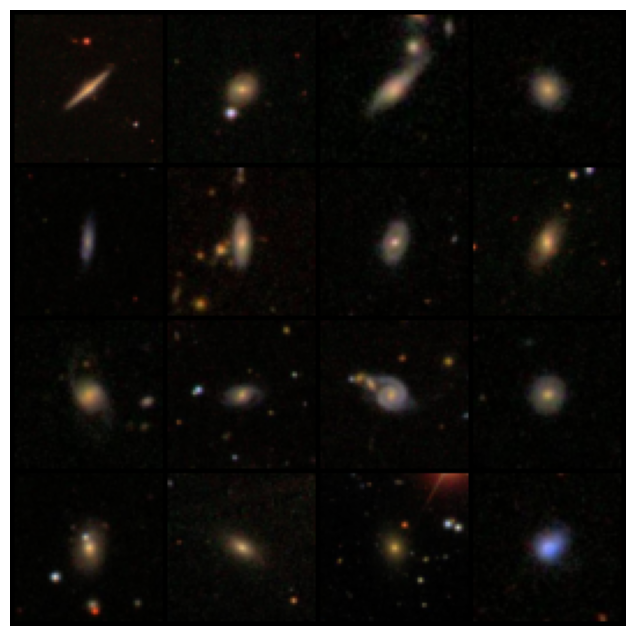

In [23]:
# TODO: un-normalise, make_grid(images[:16], nrow=4), permute, imshow, axis off.
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [ ]:
# TODO (optional): one or more stretch goals.

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?

*1. building the image folder layout*<br>
*2. for spiral, the central bulge and/or the legs*<br>
*3. spiral and spiral barred*<br>
*4. what good would be the model without an error free completely sorted and well understood data*